# ⚾ 타구 질과 구종 회피: 잘 맞을수록 더 피하는가, 결과 때문인가?

* **작성자:** CY
* **작성일:** 2026-10-05
* **목적:** 투수가 장타라는 **결과**에 반응하는지, 잘 맞았다는 **타구 질**에 반응하는지 나눠 봅니다. 결과가 나쁠수록 더 피한다는 것은 확인했지만, 장타는 대부분 잘 맞은 타구라 두 요인이 섞여 있습니다. 그래서 배럴·xwOBA가 높을수록 회피가 커지는지를 결과별로 확인합니다. `docs/추가연구_타구질.md`의 xwOBA 분석을 메인 분석과 같은 정의로 다시 계산합니다.
* **원문과 달라진 점**
  * 재대결은 **같은 경기** 안의 다음 맞대결입니다(원문은 같은 시즌).
  * 비교 기준(0점)은 **약하게 맞은 아웃**(`field_out` 중 xwOBA 하위 25%)입니다. 투수가 결과와 타구 질 모두에서 이긴 경우라, 이보다 더 피하면 "나쁜 결과나 강한 타구에 반응한 것"으로 읽을 수 있습니다.
  * 회귀에는 상황 변수(주자·아웃, 이닝, 카운트, 점수차 구간, 시즌, 구종계열)를 넣고, 표준오차는 투수별로 묶어서(cluster) 계산합니다.
* **회피 지표:** `diff = baseline − 비교 타석에서 그 구종 비율` (양수 = 평소보다 덜 던짐). baseline은 시즌 구사율(메인)과 경기 내 직전까지 구사율 두 가지입니다.
* **이벤트:** 타구가 나온 모든 타석(아웃 `field_out`, 단타, 2·3루타, 홈런) 중 비교 타석이 있는 것.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.hit_quality import (
    OUTCOME_ORDER, XWOBA, add_prior_game_usage, add_xwoba_quartile, build_batted_ball_events, cell_table,
)
from src.analysis.situation_matching import MODES, add_situation_columns
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

OUT_DIR = '../data/processed'
FIG_DIR = '../data/processed/figures'
os.makedirs(FIG_DIR, exist_ok=True)
MODE_LABELS = {'same_batter': '재대결 (메인)', 'next_batter': '다음 타자 (보조)'}
BASELINES = {'season_usage_rate': '시즌 구사율', 'baseline_usage': '경기 내 직전까지'}

## 1. 데이터 읽기

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'batter', 'stand', 'p_throws',
    'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up', 'inning', 'inning_topbot',
    'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score', 'launch_speed', 'launch_angle', XWOBA,
]
frames = [pd.read_csv(p, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False) for p in list_research_csvs()]
pitches = pd.concat(frames, ignore_index=True)
pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
assert len(pitches) == 3_592_302 and not pitches.duplicated(KEY_COLUMNS).any()

pitches = add_prior_game_usage(add_situation_columns(pitches))
season_usage = compute_season_usage_rate(pitches)
print(f'{len(pitches):,}행')

3,592,302행


## 2. 이벤트 만들기

비교 기준마다 타구 이벤트를 만들고 xwOBA 4분위(전체 타구 기준, Q1 = 가장 약한 타구)를 붙입니다.
재대결 기준 장타 수는 메인 분석과 같아야 합니다(구종 있는 27,371건).

In [3]:
events = {}
for mode in MODES:
    ev = add_xwoba_quartile(build_batted_ball_events(pitches, season_usage, mode))
    events[mode] = ev
    print(f'[{MODE_LABELS[mode]}] 타구 이벤트 {len(ev):,}건, xwOBA 있음 {ev[XWOBA].notna().mean():.1%}')
    display(ev.groupby('outcome')['barrel'].agg(n='size', barrel_rate='mean').loc[OUTCOME_ORDER].round(3))

n_xbh = events['same_batter']['outcome'].isin(['2·3루타', '홈런']).sum()
assert n_xbh == 27_371, n_xbh
print('xwOBA 분위 경계:', events['same_batter'][XWOBA].quantile([0.25, 0.5, 0.75]).round(3).tolist())

[재대결 (메인)] 타구 이벤트 223,832건, xwOBA 있음 99.7%


,n,barrel_rate
outcome,,
아웃,146500,0.033585
단타,49961,0.008647
2·3루타,16511,0.219462
홈런,10860,0.843143


[다음 타자 (보조)] 타구 이벤트 427,878건, xwOBA 있음 99.7%


,n,barrel_rate
outcome,,
아웃,240883,0.033362
단타,120978,0.008362
2·3루타,39758,0.217902
홈런,26259,0.843092


xwOBA 분위 경계: [0.075, 0.254, 0.588]


## 3. 결과 × xwOBA 분위 (약한 아웃 대비)

* `diff_mean`: 그 칸의 평균 회피 (양수 = baseline보다 덜 던짐)
* `vs_ref`: 약한 아웃(아웃·Q1)보다 얼마나 더 피했나 (%p로 보려면 ×100)

In [4]:
cells = pd.concat([
    cell_table(events[mode], base).assign(mode=mode, baseline=base)
    for mode in MODES for base in BASELINES
], ignore_index=True)
display(cells[cells['baseline'] == 'season_usage_rate']
        .pivot_table(index=['mode', 'outcome'], columns='xwoba_q', values='vs_ref', observed=True).mul(100).round(2))
cells.to_csv(f'{OUT_DIR}/hit_quality_xwoba_cells.csv', index=False)

xwoba_q                 Q1     Q2     Q3     Q4
mode        outcome                            
next_batter 아웃        0.00   0.38   1.33   1.90
            단타        0.80   1.41   4.03   4.77
            2·3루타     4.19   4.42   6.79   7.22
            홈런        6.53   7.35   7.09   8.64
same_batter 아웃        0.00  -1.11   2.95   8.62
            단타       -0.67   1.74   8.35  10.90
            2·3루타     3.67   9.14  12.65  14.95
            홈런       16.85  18.13  17.50  19.00

## 4. 배럴 (비배럴 아웃 대비)

배럴 여부 × 결과입니다. 기준은 비배럴 아웃입니다. "배럴인데 아웃"이 비배럴 아웃보다 더 피해지면, 결과가 좋아도 타구 질에 반응한다는 뜻입니다.

In [5]:
barrel = pd.concat([
    cell_table(events[mode].assign(barrel_label=events[mode]['barrel'].map({True: '배럴', False: '비배럴'})),
               base, by='barrel_label', ref=('아웃', '비배럴')).assign(mode=mode, baseline=base)
    for mode in MODES for base in BASELINES
], ignore_index=True)
display(barrel[barrel['baseline'] == 'season_usage_rate']
        .pivot_table(index=['mode', 'outcome'], columns='barrel_label', values='vs_ref', observed=True).mul(100).round(2))
barrel.to_csv(f'{OUT_DIR}/hit_quality_barrel_cells.csv', index=False)

barrel_label            배럴    비배럴
mode        outcome              
next_batter 아웃        2.04   0.00
            단타        2.13   3.25
            2·3루타     7.28   5.89
            홈런        8.21   7.10
same_batter 아웃       10.11   0.00
            단타       11.91   7.51
            2·3루타    14.50  12.13
            홈런       18.34  17.00

## 5. 회귀: 결과와 타구 질을 함께 넣으면

`diff ~ 결과 × xwOBA + 상황 변수` (OLS, 투수별 cluster 표준오차). 결과의 기준은 아웃입니다.

* `C(outcome)[T.홈런]` 등: xwOBA가 같을 때 결과 자체의 효과
* `xwoba`: 아웃에서 타구 질이 0.1 높아질 때의 효과(계수 × 0.1)
* `C(outcome)[T.홈런]:xwoba` 등: 결과마다 타구 질 효과가 아웃과 얼마나 다른가

In [6]:
SITUATION = 'C(base_out_state) + C(inning_bucket) + C(count_bucket) + C(score_diff_bucket) + C(season) + C(pitch_family)'
FORMULA = f"diff ~ C(outcome, Treatment('아웃')) * xwoba + {SITUATION}"


def fit_regression(ev, base):
    d = ev[ev[base].notna() & ev[XWOBA].notna()].copy()
    d['diff'] = d[base] - d['same_type_share']
    d['xwoba'] = d[XWOBA]
    fit = smf.ols(FORMULA, data=d).fit(cov_type='cluster', cov_kwds={'groups': d['pitcher']})
    keep = [t for t in fit.params.index if 'outcome' in t or t == 'xwoba']
    tab = pd.DataFrame({'coef': fit.params[keep], 'ci_low': fit.conf_int().loc[keep, 0],
                        'ci_high': fit.conf_int().loc[keep, 1], 'p': fit.pvalues[keep]})
    return tab, fit.nobs, fit.rsquared

reg_rows = []
for mode in MODES:
    for base in BASELINES:
        tab, n, r2 = fit_regression(events[mode], base)
        print(f'[{MODE_LABELS[mode]} / {BASELINES[base]}] n={int(n):,}, R²={r2:.3f}')
        display(tab.round(4))
        reg_rows.append(tab.assign(mode=mode, baseline=base, n=int(n), r2=r2))
pd.concat(reg_rows).to_csv(f'{OUT_DIR}/hit_quality_regression.csv')

[재대결 (메인) / 시즌 구사율] n=223,191, R²=0.045


,coef,ci_low,ci_high,p
"C(outcome, Treatment('아웃'))[T.2·3루타]",0.1098,0.1010,0.1186,0.000
"C(outcome, Treatment('아웃'))[T.단타]",0.0277,0.0214,0.0339,0.000
"C(outcome, Treatment('아웃'))[T.홈런]",0.1894,0.1773,0.2014,0.000
xwoba,0.1077,0.1007,0.1146,0.000
"C(outcome, Treatment('아웃'))[T.2·3루타]:xwoba",-0.0517,-0.0643,-0.0390,0.000
"C(outcome, Treatment('아웃'))[T.단타]:xwoba",0.0157,0.0045,0.0269,0.006
"C(outcome, Treatment('아웃'))[T.홈런]:xwoba",-0.0996,-0.1099,-0.0893,0.000


[재대결 (메인) / 경기 내 직전까지] n=219,971, R²=0.070


,coef,ci_low,ci_high,p
"C(outcome, Treatment('아웃'))[T.2·3루타]",0.1119,0.1016,0.1221,0.0000
"C(outcome, Treatment('아웃'))[T.단타]",0.0280,0.0213,0.0348,0.0000
"C(outcome, Treatment('아웃'))[T.홈런]",0.2003,0.1856,0.2150,0.0000
xwoba,0.1141,0.1065,0.1218,0.0000
"C(outcome, Treatment('아웃'))[T.2·3루타]:xwoba",-0.0505,-0.0653,-0.0357,0.0000
"C(outcome, Treatment('아웃'))[T.단타]:xwoba",0.0158,0.0034,0.0283,0.0128
"C(outcome, Treatment('아웃'))[T.홈런]:xwoba",-0.1024,-0.1147,-0.0901,0.0000


[다음 타자 (보조) / 시즌 구사율] n=426,656, R²=0.011


,coef,ci_low,ci_high,p
"C(outcome, Treatment('아웃'))[T.2·3루타]",0.0460,0.0394,0.0526,0.0000
"C(outcome, Treatment('아웃'))[T.단타]",0.0064,0.0021,0.0107,0.0033
"C(outcome, Treatment('아웃'))[T.홈런]",0.0721,0.0634,0.0809,0.0000
xwoba,0.0253,0.0207,0.0300,0.0000
"C(outcome, Treatment('아웃'))[T.2·3루타]:xwoba",0.0020,-0.0073,0.0112,0.6784
"C(outcome, Treatment('아웃'))[T.단타]:xwoba",0.0251,0.0175,0.0326,0.0000
"C(outcome, Treatment('아웃'))[T.홈런]:xwoba",-0.0169,-0.0244,-0.0094,0.0000


[다음 타자 (보조) / 경기 내 직전까지] n=417,558, R²=0.015


,coef,ci_low,ci_high,p
"C(outcome, Treatment('아웃'))[T.2·3루타]",0.0470,0.0398,0.0541,0.0000
"C(outcome, Treatment('아웃'))[T.단타]",0.0066,0.0021,0.0112,0.0044
"C(outcome, Treatment('아웃'))[T.홈런]",0.0797,0.0693,0.0902,0.0000
xwoba,0.0299,0.0249,0.0350,0.0000
"C(outcome, Treatment('아웃'))[T.2·3루타]:xwoba",0.0023,-0.0078,0.0124,0.6572
"C(outcome, Treatment('아웃'))[T.단타]:xwoba",0.0246,0.0166,0.0327,0.0000
"C(outcome, Treatment('아웃'))[T.홈런]:xwoba",-0.0197,-0.0287,-0.0107,0.0000


## 6. 그래프

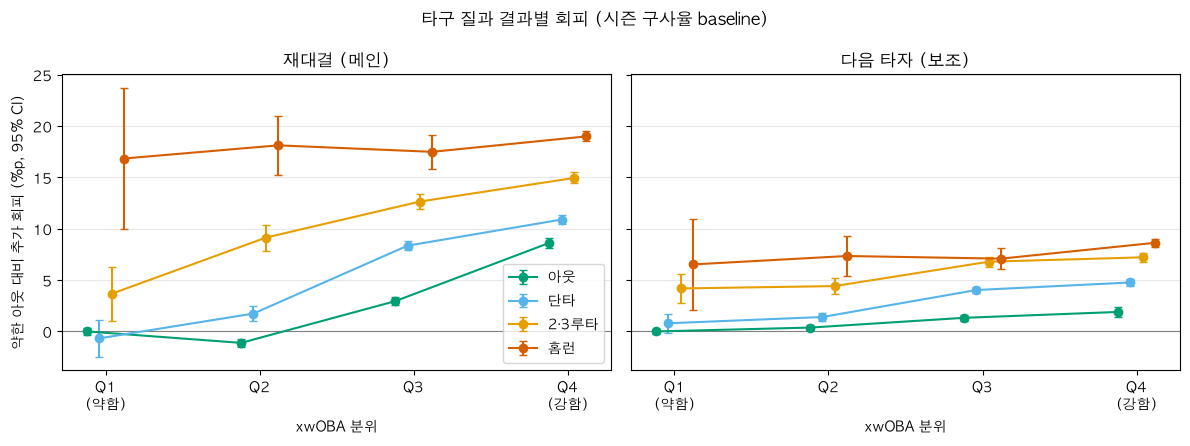

In [7]:
colors = {'아웃': '#009E73', '단타': '#56B4E9', '2·3루타': '#E69F00', '홈런': '#D55E00'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, mode in zip(axes, MODES):
    d = cells[(cells['mode'] == mode) & (cells['baseline'] == 'season_usage_rate')]
    for i, outcome in enumerate(OUTCOME_ORDER):
        o = d[d['outcome'] == outcome]
        x = np.arange(len(o)) + (i - 1.5) * 0.08
        y = o['vs_ref'] * 100
        ax.errorbar(x, y, yerr=[y - o['ci_low'] * 100, o['ci_high'] * 100 - y], fmt='o-', capsize=3,
                    color=colors[outcome], label=outcome)
    ax.set_xticks(range(4), ['Q1\n(약함)', 'Q2', 'Q3', 'Q4\n(강함)'])
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel('xwOBA 분위')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('약한 아웃 대비 추가 회피 (%p, 95% CI)')
axes[0].legend()
fig.suptitle('타구 질과 결과별 회피 (시즌 구사율 baseline)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/hit_quality_xwoba.png', dpi=150)
plt.show()

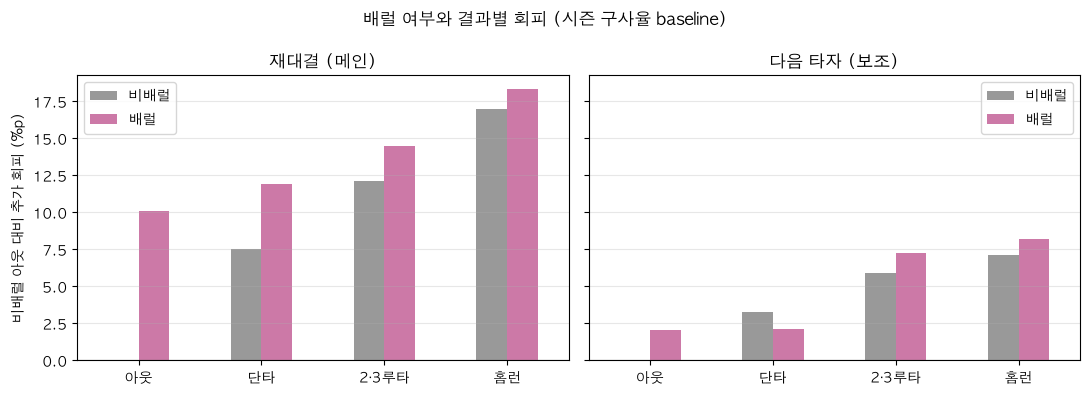

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, mode in zip(axes, MODES):
    d = barrel[(barrel['mode'] == mode) & (barrel['baseline'] == 'season_usage_rate')]
    piv = d.pivot_table(index='outcome', columns='barrel_label', values='vs_ref', observed=True).loc[OUTCOME_ORDER] * 100
    piv[['비배럴', '배럴']].plot.bar(ax=ax, color=['#999999', '#CC79A7'], rot=0)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_title(MODE_LABELS[mode])
    ax.set_xlabel('')
    ax.legend(title='')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('비배럴 아웃 대비 추가 회피 (%p)')
fig.suptitle('배럴 여부와 결과별 회피 (시즌 구사율 baseline)')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/hit_quality_barrel.png', dpi=150)
plt.show()

## 7. 해석 (시즌 구사율 baseline 기준, 경기 내 baseline도 같은 방향)

* **표본.** 재대결 타구 이벤트 223,832건(아웃 146,500, 단타 49,961, 2·3루타 16,511, 홈런 10,860), 다음 타자 427,878건. 재대결 장타 수(27,371건)는 메인 분석과 같습니다. xwOBA는 99.7%에 있습니다.
* **결과가 같아도 잘 맞을수록 더 피합니다.** 재대결에서 아웃만 보면, 약한 아웃(Q1) 대비 회피가 Q2 −1.1 → Q3 +3.0 → Q4 **+8.6%p**로 커집니다. 배럴이었던 아웃은 비배럴 아웃보다 **+10.1%p** 더 피합니다. 결과가 투수에게 좋았어도, 강하게 맞은 구종은 그 타자에게 덜 던집니다. 단타도 Q1 −0.7 → Q4 +10.9%p로 같은 모양입니다.
* **타구 질이 같아도 결과가 나쁠수록 더 피합니다.** 같은 Q4 안에서 아웃 8.6 < 단타 10.9 < 2·3루타 15.0 < 홈런 19.0%p입니다. 회귀(상황 통제)에서도 xwOBA를 고정했을 때 결과 자체의 효과가 단타 +2.8, 2·3루타 +11.0, 홈런 **+18.9%p**(아웃 대비, xwOBA = 0 지점)로 모두 유의합니다.
* **홈런은 타구 질과 거의 무관합니다.** 홈런은 Q1~Q4가 16.9~19.0%p로 평평하고(Q1은 표본이 작아 CI가 넓음), 회귀의 홈런 × xwOBA 교호작용(−0.100)이 아웃의 기울기(+0.108)를 거의 상쇄합니다. 홈런을 맞으면 타구가 어땠든 "결과"에 반응한다는 뜻입니다. 2·3루타는 기울기가 아웃의 절반 정도(0.108 − 0.052)로 남습니다.
* **다음 타자에서는 같은 방향, 절반 이하 크기.** 다음 타자 기준으로도 결과 순서(아웃 < 단타 < 2·3루타 < 홈런)와 타구 질 기울기가 모두 양수이지만, 크기가 훨씬 작습니다(홈런 Q4 8.6%p, 아웃 Q4 1.9%p, 배럴 아웃 +2.0%p). 회피는 **장타를 친 바로 그 타자에게** 훨씬 강하게 나타납니다.
* **원문과의 관계.** 방향은 원문(`docs/추가연구_타구질.md`)과 같습니다. 잘 맞은 아웃·단타는 덜 던지고, 장타는 결과 자체의 영향이 크며, 장타 안에서 타구 질의 추가 효과는 작습니다. 재대결 정의(같은 경기)와 기준(약한 아웃, 상황 통제)을 바꿔도 결론이 유지됩니다.
* **한계.**
  * 비교 기준이 매칭된 대조군이 아니라 약한 아웃이고, 상황은 회귀로만 통제했습니다. 순수 감소(노트북 03)와 숫자를 직접 비교하면 안 됩니다.
  * 같은 투수·경기의 이벤트가 여러 번 들어가 서로 독립이 아닙니다. 회귀는 투수별 cluster 표준오차로 보정했지만, 분위별 표의 CI는 독립 가정이라 실제보다 좁을 수 있습니다.
  * xwOBA 분위는 모든 타구 기준이라, 홈런 Q1·2·3루타 Q1 같은 칸은 표본이 작습니다.
  * R²는 재대결 0.045, 다음 타자 0.011로 낮습니다. 개별 타석의 구종 선택은 이 변수들로 거의 설명되지 않고, 이 분석은 평균적인 경향만 보여 줍니다.